Imports

In [1]:
import sys
!{sys.executable} -m pip install matplotlib

In [2]:
import pymc as pm

import arviz as az

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

print("Everything imported successfully!")

g++ not available, if using conda: `conda install gxx`


Everything imported successfully!


Load processed data

In [4]:
df = pd.read_csv("../data/processed/log_returns.csv")

Prepare data

In [5]:
returns = df["Log_Return"].dropna().values

idx = np.arange(len(returns))

Bayesian Model

In [6]:
with pm.Model() as model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(returns)-1
    )

    mu1 = pm.Normal("mu1",0,1)

    mu2 = pm.Normal("mu2",0,1)

    sigma = pm.HalfNormal("sigma",1)

    mu = pm.math.switch(
        idx < tau,
        mu1,
        mu2
    )

    likelihood = pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

Run MCMC

In [7]:
with model:

    trace = pm.sample(
        draws=3000,
        tune=1000,
        target_accept=0.95
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 2 chains for 1_000 tune and 3_000 draw iterations (2_000 + 6_000 draws total) took 50 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Convergence

In [8]:
pm.summary(trace)

C:\Users\melim\AppData\Local\Temp\ipykernel_13076\4130194848.py:1: DeprecationWarning: `pymc.summary` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.summary` instead.
  pm.summary(trace)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,7e+03,3e+03,540,9000,3,9,1.53,1200,880
mu1,9e-05,0.0007,-0.00058,0.00073,703,231,1.05,2.9e-05,0.00013
mu2,0,0,-0.0044,0.0042,7,9,1.22,0.00087,0.005
sigma,0.025537,0.000189,0.025,0.026,4053,3787,1.00,3e-06,2.1e-06


Trace plots

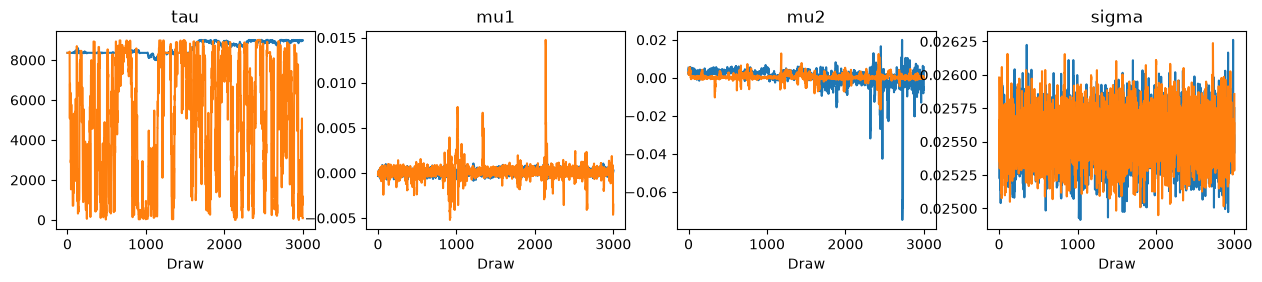

In [9]:
az.plot_trace(trace)

Posterior

In [12]:
import arviz as az

print("ArviZ version:", az.__version__)
print("ArviZ location:", az.__file__)

print("Has plot_posterior:", hasattr(az, "plot_posterior"))
print("Has plot_trace:", hasattr(az, "plot_trace"))

ArviZ version: 1.2.0
ArviZ location: c:\Users\melim\Documents\Kifiya\brent-oil-analysis\venv\Lib\site-packages\arviz\__init__.py
Has plot_posterior: False
Has plot_trace: True


In [ ]:
import arviz as az
az.plot_posterior(trace)

AttributeError: module 'arviz' has no attribute 'plot_posterior'

Posterior of tau

In [ ]:
az.plot_posterior(trace,var_names=["tau"])

Convert tau to actual date

In [ ]:
tau = int(trace.posterior["tau"].mean())

change_date = df.iloc[tau]["Date"]

Compare with events